In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, linregress
from scipy.optimize import curve_fit

C:\Users\seifert\AppData\Local\Temp\ipykernel_1984\2986097701.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
%matplotlib inline

In [4]:
def linear_funct(x, intercept, slope):
    return intercept + x * slope

def linear_fit(x, y, dy=None):
    '''
    :return: intercept, gradient, d_inter, d_gradient
    '''
    with open('outf3.csv', 'w') as f:
        for a, b, c in zip(x, y, dy):
            f.write(f"{a};{b};{c}")
    a_fit,cov=curve_fit(linear_funct ,x ,y ,sigma=dy, absolute_sigma=True)
    return a_fit[0], a_fit[1], np.sqrt(cov[0][0]), np.sqrt(cov[1][1])

In [5]:
file = r"C:\Users\seifert\Pictures\Temp\Out\TestShape4\res.csv"
file = r"D:\Dateien\KI_Speicher\LiuDimer\Sizes4\res.csv"
df = pd.read_csv(file, delimiter=';')

In [6]:
df.keys()

Index(['Unnamed: 0', 'total_id', 'img_id', 'crop_id', 'img_fn', 'crop_fn',
       'p1', 'p2', 'p1_folder', 'p2_folder', 'short_axis', 'long_axis', 'cat',
       'conf', 'w_px', 'h_px', 'grid_dist_x_nm', 'grid_dist_y_nm',
       'grid_period_x_nm', 'grid_period_y_nm', 'on_grid_percentage', 'on_grid',
       'mid_x_nm', 'mid_y_nm', 'centroid_x_nm', 'centroid_y_nm', 'NN1_nm',
       'NN2_nm', 'NN3_nm', 'NN4_nm', 'NN5_nm', 'area', 'area_nm', 'span_x_nm',
       'span_y_nm', 'span_long_axis_nm', 'span_short_axis_nm',
       'long_axis_angle', 'rect_angle', 'rect_width_nm', 'rect_height_nm',
       'rect_area_nm', 'rect_iou'],
      dtype='object')

In [7]:
confidences = df['conf']

(0.0, 1.0)

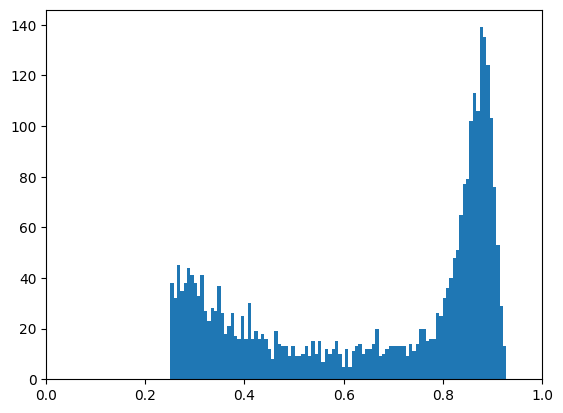

In [8]:
plt.hist(confidences, bins=100)
plt.xlim(0,1)

In [9]:
ious = df['rect_iou']

(array([  1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,
          0.,   1.,   0.,   2.,   0.,   1.,   2.,   3.,   1.,   0.,   1.,
          0.,   2.,   2.,   2.,   2.,   2.,   1.,   6.,   4.,  10.,  10.,
          9.,  10.,  17.,  12.,  19.,  12.,  19.,  26.,  26.,  48.,  35.,
         36.,  55.,  59.,  49.,  58.,  66.,  63.,  75.,  66.,  86.,  70.,
         83., 105.,  82., 105.,  84.,  94.,  99., 102.,  86., 110., 102.,
         89.,  87.,  82.,  72.,  79.,  61.,  67.,  57.,  55.,  42.,  38.,
         28.,  30.,  24.,  14.,  11.,  10.,  10.,   6.,   4.,   5.,   1.,
          1.]),
 array([0.60378569, 0.60774783, 0.61170998, 0.61567212, 0.61963426,
        0.62359641, 0.62755855, 0.63152069, 0.63548284, 0.63944498,
        0.64340712, 0.64736927, 0.65133141, 0.65529355, 0.65925569,
        0.66321784, 0.66717998, 0.67114212, 0.67510427, 0.67906641,
        0.68302855, 0.6869907 , 0.69095284, 0.

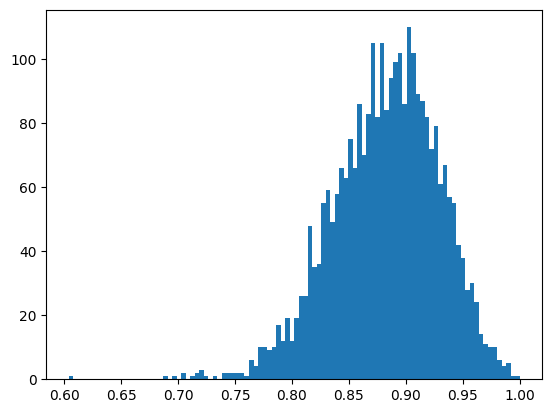

In [10]:
plt.hist(ious, bins=100)

In [11]:
on_grid_percentage = df['on_grid_percentage']

(0.0, 1.0)

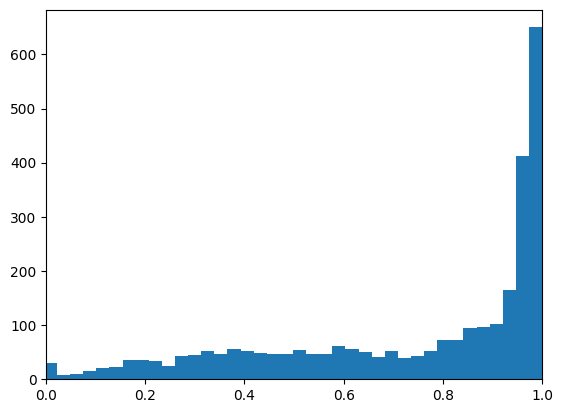

In [12]:
plt.hist(on_grid_percentage, bins=100)
plt.xlim(0, 1)

In [13]:
conf_th = 0.8

In [14]:
len(df)

2895

In [15]:
df = df[(df['conf'] > conf_th)]
len(df)

1418

In [16]:
# Filter only long axis
# df = df[df['long_axis'] == 1]

In [17]:
# len(df)

In [18]:
def density_plot(x, y, xlbl=None, ylbl=None):
    xy = np.vstack([x,y])
    z = gaussian_kde(xy)(xy)

    fig, ax = plt.subplots()
    ax.scatter(x, y, c=z, s=100)
    ax.set_xlabel(xlbl)
    ax.set_ylabel(ylbl)

In [19]:
def density_plot_spacing(x, y, xpts, xspans=None, xlbl=None, ylbl=None):

    pts_x = []
    pts_y = []
    unc_y = []
    for i, xp in enumerate(xpts):
        if i == 0:
            xlim_min = -np.inf
            xlim_max = (xpts[0] + xpts[1])/2
        elif i == len(xpts)-1:
            xlim_min = (xpts[i-1] + xpts[i])/2
            xlim_max = np.inf
        else:
            xlim_min = (xpts[i-1] + xpts[i])/2
            xlim_max = (xpts[i+1] + xpts[i])/2

        locvals = []
        for xval, yval in zip(x, y):
            if xlim_min < xval < xlim_max:
                locvals.append(yval)

        if len(locvals) > 0:
            pts_x.append(xp)
            pts_y.append(np.median(locvals))
            unc_y.append(np.sqrt(np.pi * (2 * len(locvals) + 1) / (4 * len(locvals))) * np.std(locvals) / np.sqrt(len(locvals)))


    xy = np.vstack([x,y])
    z = gaussian_kde(xy)(xy)

    fig, ax = plt.subplots()
    ax.scatter(x, y, c=z, s=100)
    ax.set_xlabel(xlbl)
    ax.set_ylabel(ylbl)

    ax.plot(pts_x, pts_y, c='red', label='median')
    ax.scatter(pts_x, pts_y, c='red', marker='x', s=50)
    ax.errorbar(pts_x, pts_y, yerr=unc_y, c='red')

    plt.legend()

In [20]:
def histo_evolution(x, y, xpts, xspans=None, xlbl=None, ylbl=None, bins=200):

    fig, ax = plt.subplots()
    keypts_x = []
    keypts_y = []
    kpy_sig = []

    mind = np.amin([abs(xpts[i] - xpts[i+1]) for i in range(len(xpts) - 1)])

    for i, xp in enumerate(xpts):
        if xspans is None:
            if i == 0:
                xlim_min = -np.inf
                xlim_max = (xpts[0] + xpts[1])/2
            elif i == len(xpts)-1:
                xlim_min = (xpts[i-1] + xpts[i])/2
                xlim_max = np.inf
            else:
                xlim_min = (xpts[i-1] + xpts[i])/2
                xlim_max = (xpts[i+1] + xpts[i])/2
        else:
            xlim_min = xp - xspans
            xlim_max = xp + xspans

        locvals = []
        for xval, yval in zip(x, y):
            if xlim_min < xval < xlim_max:
                locvals.append(yval)

        # print(locvals)
        if len(locvals) > 0:
            loc_hist = np.histogram(locvals, bins=bins)
            # print(loc_hist)
            histo_y = np.array(loc_hist[0], dtype=float)
            histo_x = np.array([(loc_hist[1][i] + loc_hist[1][i+1])/2 for i in range(len(loc_hist[1])-1)])
            histo_y/=np.amax(histo_y)
            histo_y *= mind
            histo_y += xp
            midpoint = np.median(locvals)
            keypts_x.append(midpoint)
            keypts_y.append(xp)
            n = len(locvals)
            kpy_sig.append(np.std(locvals) * np.sqrt(np.pi * (2*n+1) / (4*n)) / np.sqrt(n))
            # kpy_sig.append(np.std(locvals))
            ax.axhline(y=xp, c='gray', ls='--', alpha=0.8, lw=1)
            ax.plot(histo_x, histo_y, label=str(xp))
            ax.scatter([midpoint], [xp], marker='x', c='black', s=50)
            ax.errorbar([midpoint], [xp], xerr=kpy_sig[-1], marker='x', c='black')

    ax.set_xlabel(ylbl)
    ax.set_ylabel(xlbl)
    ax.plot(keypts_x, keypts_y, c='black', ls='--', lw=2)

    plt.legend(title=xlbl)
    with open('out2.csv', 'w') as f:
        for x, y, s in zip(keypts_x, keypts_y, kpy_sig):
            f.write(f'{y};{x};{s}\n')
    return keypts_y, keypts_x, kpy_sig

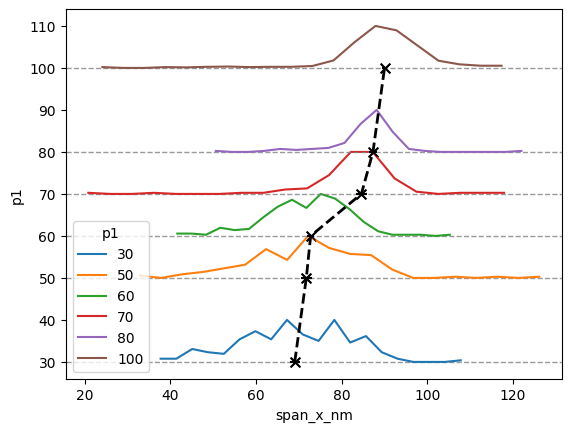

In [21]:
med_x, med_y, sig_y = histo_evolution(df['p1'], df['span_x_nm'], xpts=[10 * x for x in range(20)], xlbl='p1', ylbl='span_x_nm', bins=20)


In [22]:
def histo_and_fit(x, y, xpts, xspans=None, xlbl=None, ylbl=None, bins=200, show_span=True):
    med_x, med_y, sig_y = histo_evolution(x, y, xpts, xspans, xlbl, ylbl, bins)
    plt.show()
    plt.scatter(med_x, med_y)
    plt.errorbar(med_x, med_y, yerr=sig_y)
    plt.xlabel(xlbl)
    plt.ylabel(ylbl)

    med_x = np.array(med_x)
    med_y = np.array(med_y)
    sig_y = np.array(sig_y)

    # print(med_x.shape, med_x)
    # print(med_y.shape, med_y)
    # print(sig_y.shape, sig_y)
    res = linear_fit(med_x, med_y, sig_y)

    intercept = res[0]
    slope = res[1]
    d_intercept = res[2]
    d_slope = res[3]


    xs = np.linspace(min(med_x), max(med_x), 20)
    ys = [intercept + slope * x for x in xs]
    ys_max = [intercept + d_intercept + max( (slope + d_slope) * x, (slope - d_slope) * x) for x in xs]
    ys_min = [intercept - d_intercept + min( (slope + d_slope) * x, (slope - d_slope) * x) for x in xs]

    plt.plot(xs, ys)
    plt.plot(xs, ys_max, lw=1, c='gray', ls='--')
    plt.plot(xs, ys_min, lw=1, c='gray', ls='--')

    plt.title(f"({slope:.3f} $\pm$ {d_slope:.3f})x + ({intercept:.3f} $\pm$ {d_intercept:.3f})")

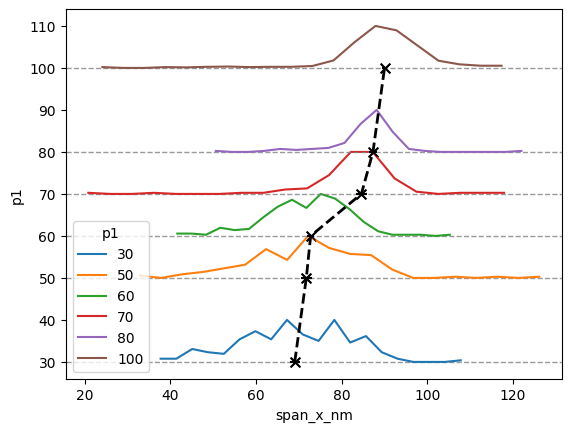

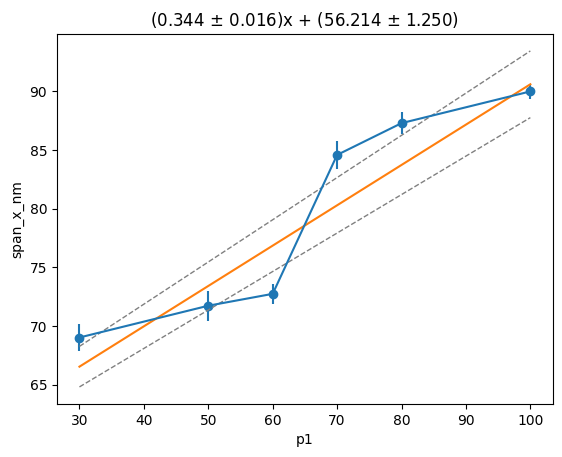

In [23]:
histo_and_fit(df['p1'], df['span_x_nm'], xpts=[10 * x for x in range(20)], xlbl='p1', ylbl='span_x_nm', bins=20)

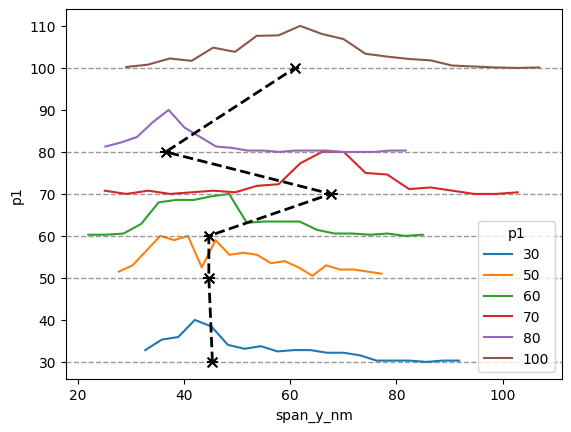

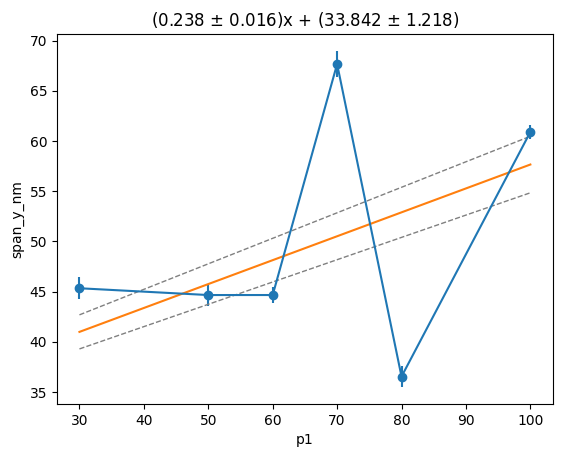

In [24]:
histo_and_fit(df['p1'], df['span_y_nm'], xpts=[10 * x for x in range(20)], xlbl='p1', ylbl='span_y_nm', bins=20)


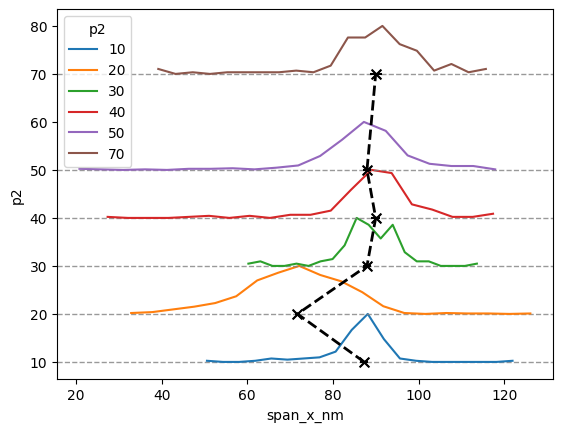

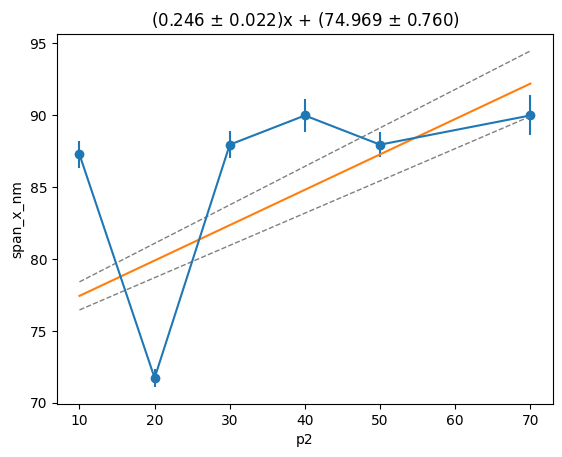

In [25]:
histo_and_fit(df['p2'], df['span_x_nm'], xpts=[10 * x for x in range(20)], xlbl='p2', ylbl='span_x_nm', bins=20)


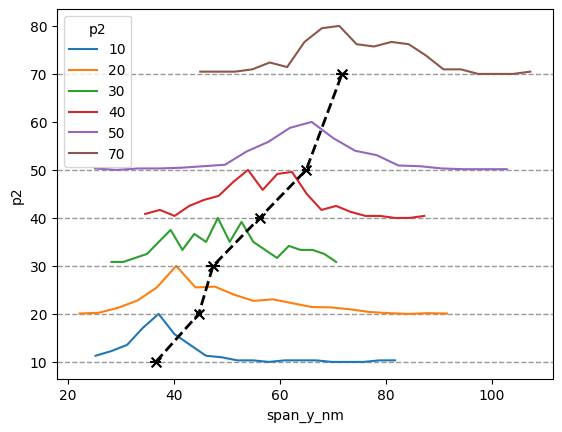

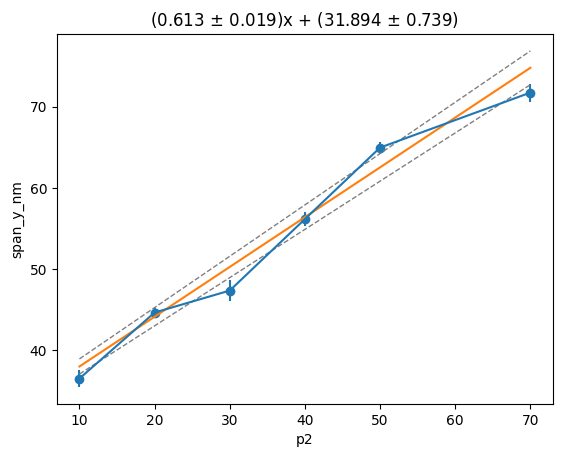

In [26]:
histo_and_fit(df['p2'], df['span_y_nm'], xpts=[10 * x for x in range(20)], xlbl='p2', ylbl='span_y_nm', bins=20)


In [27]:
def plot_polar(ang, rad):
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
    ax.plot(ang, rad)
    ax.grid(True)

In [28]:
df['short_axis']

20      1
21      1
22      1
23      1
24      1
       ..
2890    0
2891    0
2892    0
2893    0
2894    0
Name: short_axis, Length: 1418, dtype: int64

In [29]:
p_x = [a if b==1 else c for a, b, c in zip(df['p1'], df['short_axis'], df['p2'])]

In [30]:
p_y = [a if b==1 else c for a, b, c in zip(df['p1'], df['long_axis'], df['p2'])]


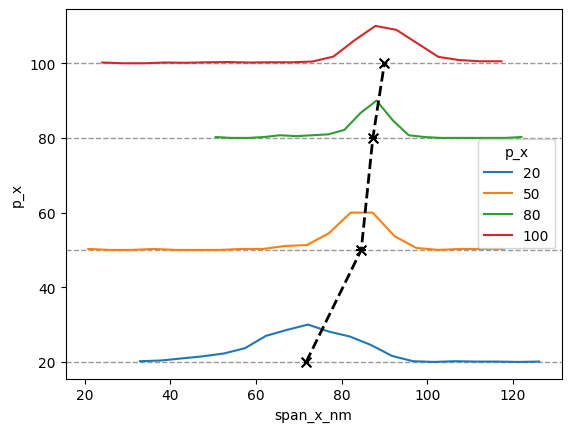

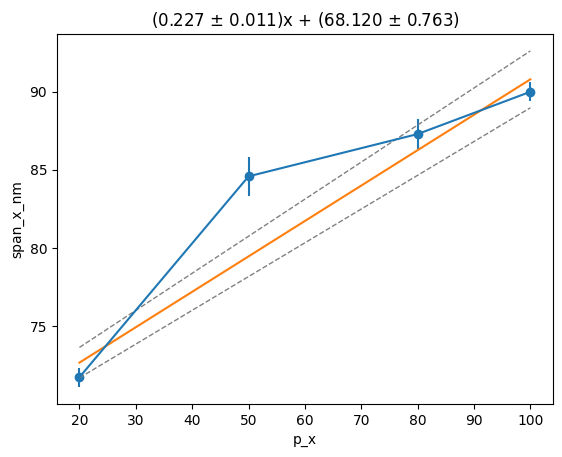

In [31]:
xvals = [p_x[i] for i in range(len(p_x)) if list(df['short_axis'])[i] + list(df['long_axis'])[i] == 1]
yvals = [list(df['span_x_nm'])[i] for i in range(len(p_x)) if list(df['short_axis'])[i] + list(df['long_axis'])[i] == 1]
histo_and_fit(xvals, yvals, xpts=[10 * x for x in range(20)], xlbl='p_x', ylbl='span_x_nm', bins=20)


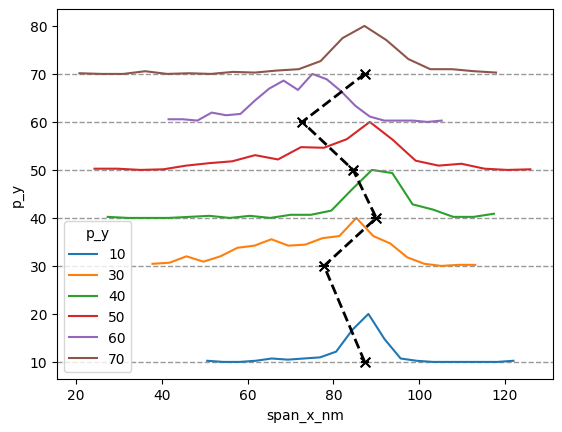

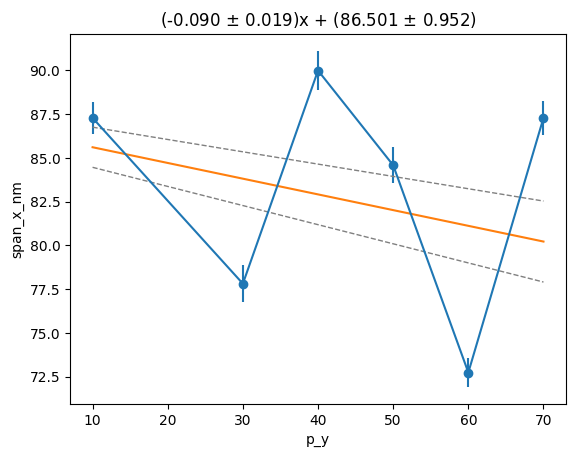

In [32]:
xvals = [p_y[i] for i in range(len(p_x)) if list(df['short_axis'])[i] + list(df['long_axis'])[i] == 1]
yvals = [list(df['span_x_nm'])[i] for i in range(len(p_x)) if list(df['short_axis'])[i] + list(df['long_axis'])[i] == 1]
histo_and_fit(xvals, yvals, xpts=[10 * x for x in range(20)], xlbl='p_y', ylbl='span_x_nm', bins=20)


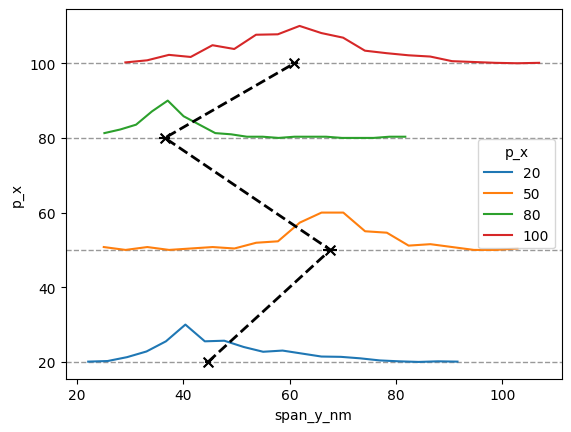

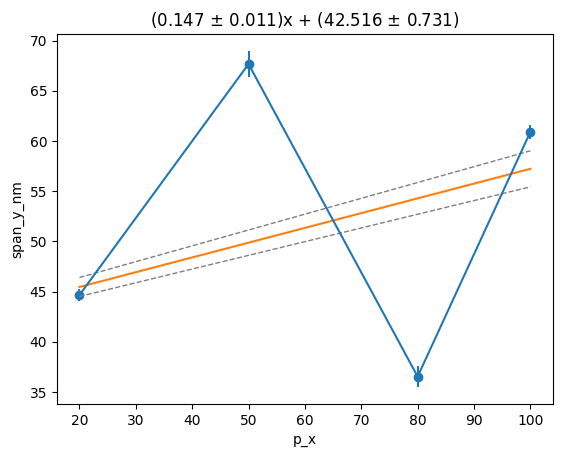

In [33]:
histo_and_fit(p_x, df['span_y_nm'], xpts=[10 * x for x in range(20)], xlbl='p_x', ylbl='span_y_nm', bins=20)


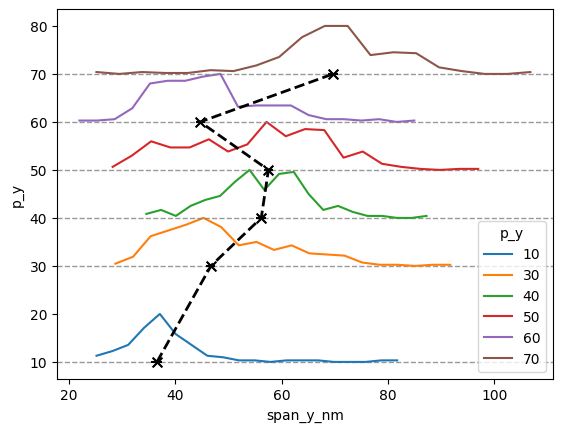

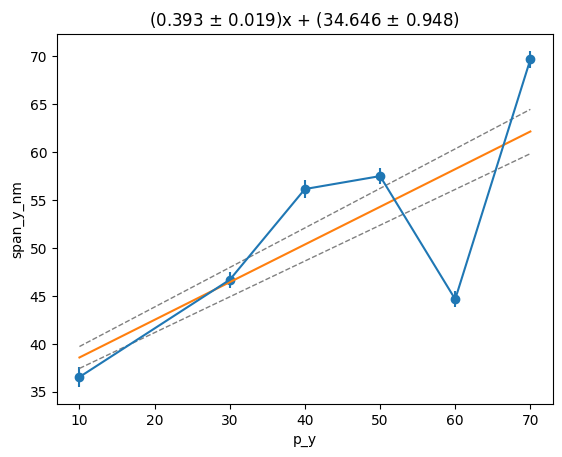

In [34]:
histo_and_fit(p_y, df['span_y_nm'], xpts=[10 * x for x in range(20)], xlbl='p_y', ylbl='span_y_nm', bins=20)


Text(0.5, 0, 'Span X')

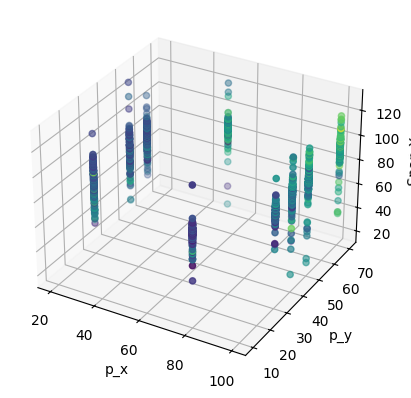

In [35]:
# %matplotlib gtk

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

xs = []
ys = []
zs = []
cs = []
for x, y, spx, spy in zip(p_x, p_y, df['span_x_nm'], df['span_y_nm']):
    xs.append(x)
    ys.append(y)
    zs.append(spx)
    cs.append(spy)
ax.scatter(xs, ys, zs, c=cs)
ax.set_xlabel('p_x')
ax.set_ylabel('p_y')
ax.set_zlabel('Span X')

In [39]:
p_x = [a if b==1 else c for a, b, c in zip(df['p1'], df['short_axis'], df['p2'])]
p_y = [a if b==0 else c for a, b, c in zip(df['p1'], df['short_axis'], df['p2'])]
df['p_x'] = p_x
df['p_y'] = p_y

In [56]:
corr = df.corr(numeric_only=True)
corr.style.background_gradient(cmap='coolwarm').format('{:.2f}')

F:\Anaconda\envs\LiuDimer\Lib\site-packages\pandas\io\formats\style.py:3807: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
F:\Anaconda\envs\LiuDimer\Lib\site-packages\pandas\io\formats\style.py:3808: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,Unnamed: 0,total_id,img_id,crop_id,p1,p2,p1_folder,p2_folder,short_axis,long_axis,cat,conf,w_px,h_px,grid_dist_x_nm,grid_dist_y_nm,grid_period_x_nm,grid_period_y_nm,on_grid_percentage,on_grid,mid_x_nm,mid_y_nm,centroid_x_nm,centroid_y_nm,NN1_nm,NN2_nm,NN3_nm,NN4_nm,NN5_nm,area,area_nm,span_x_nm,span_y_nm,span_long_axis_nm,span_short_axis_nm,long_axis_angle,rect_angle,rect_width_nm,rect_height_nm,rect_area_nm,rect_iou,p_x,p_y
Unnamed: 0,1.00,1.00,0.99,-0.53,-0.97,-0.73,-0.94,-0.79,-0.86,0.86,nan,0.01,nan,nan,0.22,0.25,0.09,0.12,-0.36,-0.33,-0.02,-0.05,-0.02,-0.05,0.27,0.54,0.63,0.56,0.56,-0.70,-0.70,-0.56,-0.43,-0.65,-0.66,-0.09,-0.06,-0.57,-0.45,-0.53,-0.36,-0.92,-0.21
total_id,1.00,1.00,0.99,-0.53,-0.97,-0.73,-0.94,-0.79,-0.86,0.86,nan,0.01,nan,nan,0.22,0.25,0.09,0.12,-0.36,-0.33,-0.02,-0.05,-0.02,-0.05,0.27,0.54,0.63,0.56,0.56,-0.70,-0.70,-0.56,-0.43,-0.65,-0.66,-0.09,-0.06,-0.57,-0.45,-0.53,-0.36,-0.92,-0.21
img_id,0.99,0.99,1.00,-0.51,-0.97,-0.67,-0.95,-0.73,-0.83,0.83,nan,0.00,nan,nan,0.22,0.25,0.06,0.09,-0.36,-0.34,-0.02,-0.06,-0.02,-0.06,0.27,0.53,0.61,0.54,0.54,-0.67,-0.67,-0.56,-0.39,-0.63,-0.62,-0.09,-0.08,-0.56,-0.46,-0.54,-0.36,-0.89,-0.20
crop_id,-0.53,-0.53,-0.51,1.00,0.53,0.38,0.54,0.42,0.55,-0.55,nan,0.33,nan,nan,-0.13,-0.09,-0.27,-0.28,0.10,0.09,0.03,0.08,0.03,0.08,-0.29,-0.48,-0.53,-0.50,-0.54,0.42,0.42,0.37,0.26,0.42,0.38,0.05,0.02,0.37,0.27,0.33,0.22,0.55,-0.01
p1,-0.97,-0.97,-0.97,0.53,1.00,0.65,0.97,0.70,0.89,-0.89,nan,-0.02,nan,nan,-0.23,-0.24,-0.09,-0.14,0.36,0.34,0.02,0.06,0.02,0.06,-0.29,-0.56,-0.64,-0.57,-0.57,0.65,0.65,0.57,0.36,0.63,0.60,0.10,0.10,0.58,0.47,0.55,0.37,0.94,0.11
p2,-0.73,-0.73,-0.67,0.38,0.65,1.00,0.55,0.99,0.47,-0.47,nan,0.12,nan,nan,-0.08,-0.18,-0.05,-0.04,0.20,0.16,0.01,0.01,0.01,0.01,-0.18,-0.36,-0.43,-0.40,-0.41,0.79,0.79,0.40,0.69,0.59,0.78,0.05,-0.09,0.41,0.28,0.35,0.23,0.64,0.61
p1_folder,-0.94,-0.94,-0.95,0.54,0.97,0.55,1.00,0.63,0.95,-0.95,nan,-0.03,nan,nan,-0.24,-0.25,-0.12,-0.18,0.37,0.35,0.02,0.07,0.02,0.07,-0.30,-0.57,-0.65,-0.59,-0.58,0.59,0.59,0.58,0.28,0.63,0.53,0.10,0.12,0.60,0.48,0.57,0.38,0.96,-0.08
p2_folder,-0.79,-0.79,-0.73,0.42,0.70,0.99,0.63,1.00,0.55,-0.55,nan,0.11,nan,nan,-0.10,-0.20,-0.07,-0.05,0.24,0.19,0.00,0.02,0.00,0.02,-0.21,-0.40,-0.48,-0.44,-0.45,0.80,0.80,0.44,0.67,0.62,0.78,0.06,-0.07,0.45,0.32,0.40,0.26,0.70,0.53
short_axis,-0.86,-0.86,-0.83,0.55,0.89,0.47,0.95,0.55,1.00,-1.00,nan,-0.08,nan,nan,-0.24,-0.22,-0.21,-0.28,0.32,0.32,0.01,0.07,0.01,0.07,-0.29,-0.58,-0.65,-0.58,-0.57,0.52,0.52,0.54,0.23,0.59,0.46,0.09,0.12,0.58,0.45,0.55,0.36,0.97,-0.27
long_axis,0.86,0.86,0.83,-0.55,-0.89,-0.47,-0.95,-0.55,-1.00,1.00,nan,0.08,nan,nan,0.24,0.22,0.21,0.28,-0.32,-0.32,-0.01,-0.07,-0.01,-0.07,0.29,0.58,0.65,0.58,0.57,-0.52,-0.52,-0.54,-0.23,-0.59,-0.46,-0.09,-0.12,-0.58,-0.45,-0.55,-0.36,-0.97,0.27


In [50]:
df_short = pd.DataFrame()

In [51]:
#df_short['p1'] = df['p1']
#df_short['p2'] = df['p2']
df_short['p_x'] = df['p_x']
df_short['p_y'] = df['p_y']
df_short['span_x_nm'] = df['span_x_nm']
df_short['span_y_nm'] = df['span_y_nm']
##df_short['span_short_axis_nm'] = df['span_short_axis_nm']
#df_short['span_long_axis_nm'] = df['span_long_axis_nm']
#df_short['rect_width_nm'] = df['rect_width_nm']
#df_short['rect_height_nm'] = df['rect_height_nm']


In [52]:
corr = df_short.corr(numeric_only=True)
corr.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1)

,p_x,p_y,span_x_nm,span_y_nm
p_x,1.000000,-0.104566,0.583160,0.359840
p_y,-0.104566,1.000000,-0.001665,0.457676
span_x_nm,0.583160,-0.001665,1.000000,0.199872
span_y_nm,0.359840,0.457676,0.199872,1.000000
